# MATH 616: Computational Linear Algebra
## Week 3 Lab — Schur Decomposition, the Spectral Theorem, and Positive Semidefinite Matrices

This notebook develops the **definitions, algorithms, and computational examples** for this week's topics.

### Learning goals
By the end of the lab you should be able to:

- explain why Schur decomposition is useful and why it is preferable to eigenvector diagonalization for a general square matrix;
- compute and verify real and complex Schur decompositions;
- understand Hessenberg reduction and QR iteration at an algorithmic level;
- use the spectral theorem for symmetric/Hermitian matrices;
- compute matrix functions from an orthogonal eigendecomposition;
- characterize positive semidefinite (PSD) and positive definite (PD) matrices;
- test PSD numerically and use Cholesky factorization for PD systems;
- recognize PSD matrices arising as Gram and covariance matrices.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import schur, hessenberg, cholesky

np.set_printoptions(precision=5, suppress=True)
rng = np.random.default_rng(616)

# Part I. Why Schur Decomposition?

A familiar goal is diagonalization,

\[
A=X\Lambda X^{-1}.
\]

It is attractive because powers and matrix functions become simple. But two things can go wrong:

1. **Diagonalization may not exist.** A defective matrix may not have enough linearly independent eigenvectors.
2. **The eigenvector basis may be numerically dangerous.** If the eigenvectors are nearly parallel, \(X\) is ill-conditioned and \(X^{-1}\) amplifies errors.

Schur decomposition avoids both difficulties by replacing an arbitrary eigenvector basis with an **orthogonal/unitary basis**.

## 1. A defective matrix

Consider

\[
A=\begin{bmatrix}1&1\\0&1\end{bmatrix}.
\]

It has a repeated eigenvalue but only one independent eigenvector, so it is not diagonalizable.

In [2]:
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])

evals, evecs = np.linalg.eig(A)
print('Eigenvalues:', evals)
print('Eigenvector matrix:')
print(evecs)
print('Rank of eigenvector matrix =', np.linalg.matrix_rank(evecs))

Eigenvalues: [1. 1.]
Eigenvector matrix:
[[ 1. -1.]
 [ 0.  0.]]
Rank of eigenvector matrix = 1


# Part II. Schur Decomposition

## Complex Schur theorem

For every square matrix \(A\in\mathbb C^{n\times n}\), there exists a unitary matrix \(Q\) and an upper triangular matrix \(T\) such that

\[
\boxed{A=QTQ^*}.
\]

Equivalently,

\[
Q^*AQ=T.
\]

Because \(T\) is triangular, its diagonal entries are the eigenvalues of \(A\).

### Why this is important

- the factorization exists for **every** square matrix;
- \(Q^{-1}=Q^*\), so the basis change is perfectly conditioned in the 2-norm;
- eigenvalues are exposed without requiring a complete eigenvector basis;
- the columns of \(Q\) provide numerically stable invariant subspaces;
- practical dense eigenvalue algorithms are designed to compute Schur form.

## 2. Compute a complex Schur decomposition

In [3]:
A = np.array([[1.0, 4.0, 2.0],
              [0.0, 2.0, 3.0],
              [-1.0, 0.0, 1.0]])

T, Q = schur(A, output='complex')

print('T =')
print(T)
print('\n||A - Q T Q*||_F =', np.linalg.norm(A - Q @ T @ Q.conj().T, 'fro'))
print('||Q*Q - I||_F =', np.linalg.norm(Q.conj().T @ Q - np.eye(3), 'fro'))

T =
[[ 2.30556+2.12187j  1.06903-0.72326j  2.21396+2.97675j]
 [ 0.     +0.j      -0.61112-0.j       0.51408+0.54561j]
 [ 0.     +0.j       0.     +0.j       2.30556-2.12187j]]

||A - Q T Q*||_F = 6.885222889556361e-15
||Q*Q - I||_F = 1.1555883466601509e-15


The eigenvalues of \(A\) should match the diagonal of \(T\), possibly in a different order.

In [4]:
eigvals = np.linalg.eigvals(A)
print('eig(A)     =', eigvals)
print('diag(T)    =', np.diag(T))
print('Same set?  =', np.allclose(np.sort_complex(eigvals), np.sort_complex(np.diag(T))))

eig(A)     = [-0.61112+0.j       2.30556+2.12187j  2.30556-2.12187j]
diag(T)    = [ 2.30556+2.12187j -0.61112-0.j       2.30556-2.12187j]
Same set?  = False


## 3. Real Schur form

For a real matrix, one may keep the arithmetic real:

\[
A=QTQ^T,
\]

where \(Q\) is real orthogonal and \(T\) is **quasi-upper-triangular**. Real eigenvalues appear in \(1\times1\) blocks and complex-conjugate pairs appear in \(2\times2\) blocks.

A rotation matrix is the simplest example.

In [5]:
R = np.array([[0.0, -1.0],
              [1.0,  0.0]])

T_real, Q_real = schur(R, output='real')
T_complex, Q_complex = schur(R, output='complex')

print('Real Schur form:')
print(T_real)
print('\nComplex Schur form:')
print(T_complex)
print('\nEigenvalues:', np.linalg.eigvals(R))

Real Schur form:
[[ 0. -1.]
 [ 1.  0.]]

Complex Schur form:
[[ 0.+1.j -0.+0.j]
 [ 0.+0.j  0.-1.j]]

Eigenvalues: [0.+1.j 0.-1.j]


## 4. Schur vectors and invariant subspaces

Partition

\[
Q=[Q_1\;Q_2],\qquad
T=\begin{bmatrix}T_{11}&T_{12}\\0&T_{22}\end{bmatrix}.
\]

Then

\[
AQ_1=Q_1T_{11}.
\]

Thus the columns of \(Q_1\) span an invariant subspace of \(A\).

In [6]:
k = 2
Q1 = Q[:, :k]
T11 = T[:k, :k]
print('||A Q1 - Q1 T11||_F =', np.linalg.norm(A @ Q1 - Q1 @ T11, 'fro'))

||A Q1 - Q1 T11||_F = 3.675296119187823e-15


# Part III. Algorithmic Route to Schur Form

Modern dense eigensolvers do **not** find roots of the characteristic polynomial. The standard route is

\[
A\longrightarrow H\longrightarrow T,
\]

where:

1. \(A\) is reduced to **upper Hessenberg form** using Householder reflections;
2. shifted **QR iteration** drives the Hessenberg matrix toward Schur form.

## 5. Hessenberg reduction

An upper Hessenberg matrix satisfies

\[
h_{ij}=0\qquad\text{for }i>j+1.
\]

For example,

\[
H=\begin{bmatrix}
*&*&*&*\\
*&*&*&*\\
0&*&*&*\\
0&0&*&*
\end{bmatrix}.
\]

Householder transformations produce

\[
H=Q_H^TAQ_H.
\]

The benefit is computational: QR steps on a Hessenberg matrix are much cheaper than QR steps on a full dense matrix.

In [7]:
A = rng.standard_normal((5, 5))
H, QH = hessenberg(A, calc_q=True)

print('H =')
print(H)
print('\n||A - QH H QH^T||_F =', np.linalg.norm(A - QH @ H @ QH.T, 'fro'))
print('Norm below first subdiagonal =', np.linalg.norm(np.tril(H, -2)))

H =
[[ 0.29723  0.48975  1.79284 -1.67298 -1.28244]
 [-1.90312 -0.62944 -1.94824  0.61359  0.84246]
 [ 0.      -2.48571 -1.34063 -0.33382  0.27457]
 [ 0.       0.       2.1767  -0.13802 -0.21354]
 [ 0.       0.       0.       0.08614  0.46309]]

||A - QH H QH^T||_F = 1.889533561266819e-15
Norm below first subdiagonal = 0.0


## 6. Basic QR iteration

The simplest QR iteration is

\[
A_k=Q_kR_k,\qquad A_{k+1}=R_kQ_k.
\]

Since

\[
A_{k+1}=Q_k^TA_kQ_k,
\]

this is an orthogonal similarity transformation and therefore preserves eigenvalues.

### Pseudocode

```text
A0 = A
for k = 0,1,2,...
    Qk, Rk = qr(Ak)
    Ak+1 = Rk Qk
end
```

Practical implementations add **shifts, deflation, and implicit QR steps**.

In [8]:
def qr_iteration(A, nsteps=40):
    Ak = np.array(A, dtype=float)
    history = [Ak.copy()]
    for _ in range(nsteps):
        Qk, Rk = np.linalg.qr(Ak)
        Ak = Rk @ Qk
        history.append(Ak.copy())
    return Ak, history

Aq = np.array([[4.0, 1.0, 2.0],
               [1.0, 3.0, 0.5],
               [2.0, 0.5, 1.0]])

Afinal, history = qr_iteration(Aq)
print('After QR iteration:')
print(Afinal)
print('\nTrue eigenvalues:', np.linalg.eigvalsh(Aq))

After QR iteration:
[[ 5.5 -0.  -0. ]
 [-0.   2.5 -0. ]
 [ 0.   0.   0. ]]

True eigenvalues: [-0.   2.5  5.5]


### Track convergence for the symmetric example

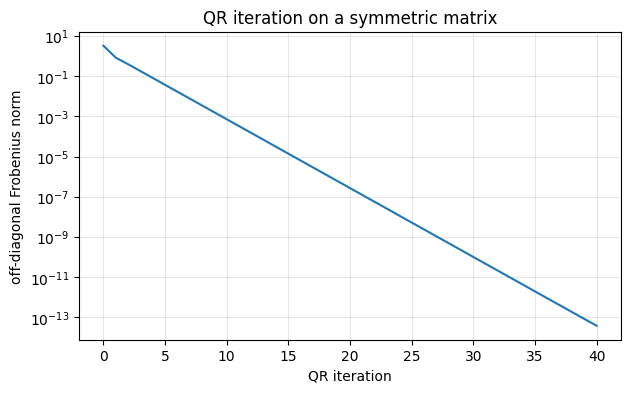

In [9]:
offdiag = []
for Ak in history:
    offdiag.append(np.linalg.norm(Ak - np.diag(np.diag(Ak)), 'fro'))

plt.figure(figsize=(7,4))
plt.semilogy(offdiag)
plt.xlabel('QR iteration')
plt.ylabel('off-diagonal Frobenius norm')
plt.title('QR iteration on a symmetric matrix')
plt.grid(True, alpha=0.3)
plt.show()

# Part IV. The Spectral Theorem

Schur decomposition applies to every square matrix. Symmetric/Hermitian matrices have a stronger structure.

## Spectral theorem

If

\[
A=A^T\in\mathbb R^{n\times n},
\]

then there exists an orthogonal matrix \(Q\) and a real diagonal matrix \(\Lambda\) such that

\[
\boxed{A=Q\Lambda Q^T}.
\]

The columns of \(Q\) are orthonormal eigenvectors of \(A\).

For a complex Hermitian matrix \(A=A^*\),

\[
A=Q\Lambda Q^*,
\]

with real eigenvalues.

### Why symmetry upgrades Schur form

Schur gives \(Q^TAQ=T\). If \(A\) is symmetric, then \(T\) is both upper triangular and symmetric. The only such matrix is diagonal. Hence the Schur decomposition becomes the spectral decomposition.

## 7. Spectral decomposition with `numpy.linalg.eigh`

In [10]:
S = np.array([[4.0, 1.0, 2.0],
              [1.0, 3.0, 0.0],
              [2.0, 0.0, 2.0]])

lam, Q = np.linalg.eigh(S)

print('Eigenvalues:', lam)
print('\nQ^T Q =')
print(Q.T @ Q)
print('\nReconstruction error =', np.linalg.norm(S - Q @ np.diag(lam) @ Q.T, 'fro'))

Eigenvalues: [0.63853 2.83255 5.52892]

Q^T Q =
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Reconstruction error = 1.9195524781125286e-15


Use `np.linalg.eigh` rather than `np.linalg.eig` for symmetric/Hermitian matrices because it exploits the structure and returns an orthonormal eigenbasis.

## 8. Rank-one spectral expansion

From

\[
A=Q\Lambda Q^T,
\]

we obtain

\[
A=\sum_{i=1}^n \lambda_i q_iq_i^T.
\]

This is the symmetric analogue of the rank-one SVD expansion.

In [11]:
terms = [lam[i] * np.outer(Q[:, i], Q[:, i]) for i in range(len(lam))]
print('Reconstruction from rank-one spectral terms:')
print(sum(terms))

Reconstruction from rank-one spectral terms:
[[ 4.  1.  2.]
 [ 1.  3. -0.]
 [ 2. -0.  2.]]


# Part V. Matrix Functions from the Spectral Theorem

For a symmetric matrix

\[
A=Q\Lambda Q^T,
\]

define

\[
f(A)=Qf(\Lambda)Q^T.
\]

Examples include

\[
A^k=Q\Lambda^kQ^T,
\qquad
\exp(A)=Q\exp(\Lambda)Q^T.
\]

For a PSD matrix, the principal square root is

\[
A^{1/2}=Q\Lambda^{1/2}Q^T.
\]

## 9. Matrix square root

In [12]:
B = np.array([[2.0, 1.0],
              [1.0, 2.0]])

lamB, QB = np.linalg.eigh(B)
sqrtB = QB @ np.diag(np.sqrt(lamB)) @ QB.T

print('B^(1/2) =')
print(sqrtB)
print('\n||B^(1/2) B^(1/2) - B||_F =', np.linalg.norm(sqrtB @ sqrtB - B, 'fro'))

B^(1/2) =
[[1.36603 0.36603]
 [0.36603 1.36603]]

||B^(1/2) B^(1/2) - B||_F = 1.0532500405730103e-15


# Part VI. Positive Semidefinite Matrices

## Definition

A real symmetric matrix \(A\) is **positive semidefinite (PSD)** if

\[
\boxed{x^TAx\ge 0\quad\text{for every }x\in\mathbb R^n.}
\]

We write

\[
A\succeq 0.
\]

It is **positive definite (PD)** if

\[
x^TAx>0\quad\text{for every }x\ne0,
\]

written \(A\succ0\).

## Equivalent characterizations

For a real symmetric matrix \(A\), the following are equivalent:

1. \(A\succeq0\);
2. \(x^TAx\ge0\) for all \(x\);
3. every eigenvalue satisfies \(\lambda_i\ge0\);
4. there exists a matrix \(B\) such that \(A=B^TB\);
5. \(A\) is a Gram matrix.

For positive definiteness,

\[
A\succ0 \iff \lambda_i>0\quad\text{for every }i.
\]

### Eigenvalue proof

If \(A=Q\Lambda Q^T\) and \(y=Q^Tx\), then

\[
x^TAx=y^T\Lambda y=\sum_i\lambda_i y_i^2.
\]

Therefore the quadratic form is nonnegative for every \(x\) exactly when all eigenvalues are nonnegative.

## 10. PSD, PD, and indefinite examples

In [13]:
A_psd = np.array([[1.0, 1.0],
                  [1.0, 1.0]])
A_pd = np.array([[2.0, 1.0],
                 [1.0, 2.0]])
A_indef = np.array([[1.0, 0.0],
                    [0.0,-1.0]])

for name, M in [('PSD', A_psd), ('PD', A_pd), ('indefinite', A_indef)]:
    print(f'{name:12s}: eigenvalues = {np.linalg.eigvalsh(M)}')

PSD         : eigenvalues = [0. 2.]
PD          : eigenvalues = [1. 3.]
indefinite  : eigenvalues = [-1.  1.]


A PSD matrix may be singular. A PD matrix cannot be singular. An indefinite matrix has both positive and negative eigenvalues.

# Part VII. Geometry of Quadratic Forms

For symmetric \(A\),

\[
q(x)=x^TAx.
\]

In eigenvector coordinates,

\[
q(x)=\sum_i\lambda_i y_i^2.
\]

The eigenvectors give the principal axes; the eigenvalues determine the curvature along those axes.

## 11. Positive-definite quadratic form

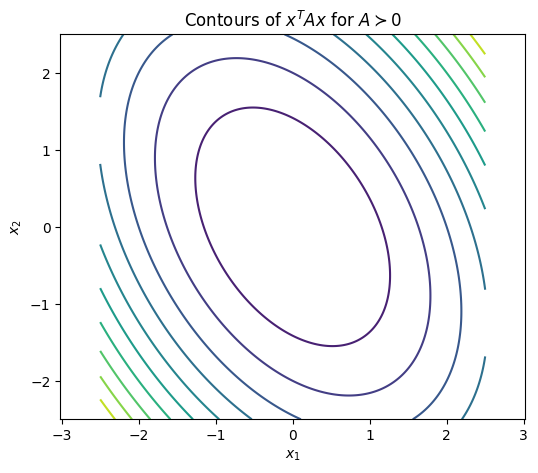

In [14]:
Aqf = np.array([[3.0, 1.0],
                [1.0, 2.0]])

grid = np.linspace(-2.5, 2.5, 250)
X1, X2 = np.meshgrid(grid, grid)
Z = Aqf[0,0]*X1**2 + 2*Aqf[0,1]*X1*X2 + Aqf[1,1]*X2**2

plt.figure(figsize=(6,5))
plt.contour(X1, X2, Z, levels=12)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title(r'Contours of $x^T A x$ for $A \succ 0$')
plt.axis('equal')
plt.show()

## 12. Indefinite quadratic form

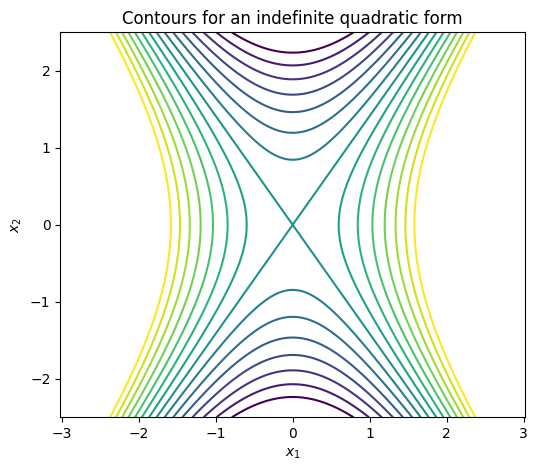

In [15]:
Aind = np.diag([2.0, -1.0])
Z2 = Aind[0,0]*X1**2 + Aind[1,1]*X2**2

plt.figure(figsize=(6,5))
plt.contour(X1, X2, Z2, levels=np.linspace(-5,5,15))
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Contours for an indefinite quadratic form')
plt.axis('equal')
plt.show()

# Part VIII. Numerical PSD Testing

For a matrix that should theoretically be symmetric, a practical numerical test is:

1. check symmetry;
2. compute the smallest eigenvalue with a symmetric eigensolver;
3. compare it against a tolerance.

Do **not** test with exact equality because a theoretically zero eigenvalue may appear as a tiny negative number because of roundoff.

## 13. A simple PSD test

In [16]:
def is_psd(A, tol=1e-10):
    A = np.asarray(A, dtype=float)
    if not np.allclose(A, A.T, atol=tol, rtol=0):
        return False
    return np.linalg.eigvalsh(A)[0] >= -tol

print('A_psd   ->', is_psd(A_psd))
print('A_pd    ->', is_psd(A_pd))
print('A_indef ->', is_psd(A_indef))

A_psd   -> True
A_pd    -> True
A_indef -> False


A scale-aware tolerance can be based on machine precision and matrix size, for example

\[
\mathrm{tol}=c\,\epsilon_{\rm mach}\|A\|_2.
\]

# Part IX. Gram and Covariance Matrices

## Gram matrices

For any matrix \(X\),

\[
G=X^TX
\]

is PSD because

\[
z^TGz=z^TX^TXz=\|Xz\|_2^2\ge0.
\]

## 14. Gram matrix example

In [17]:
X = rng.standard_normal((6,4))
G = X.T @ X
print('Eigenvalues of X^T X:')
print(np.linalg.eigvalsh(G))
print('PSD?', is_psd(G))

Eigenvalues of X^T X:
[ 0.31621  4.60393  7.90112 11.82671]
PSD? True


## Covariance matrices

For centered data \(X\in\mathbb R^{m\times n}\),

\[
C=\frac{1}{m-1}X^TX.
\]

Therefore every covariance matrix is PSD. This is exactly why all PCA variances are nonnegative.

In [18]:
data = rng.standard_normal((100,3))
data[:,1] = 0.8*data[:,0] + 0.2*data[:,1]
Xc = data - data.mean(axis=0)
C = Xc.T @ Xc / (len(data)-1)

print('Covariance matrix:')
print(C)
print('\nEigenvalues:')
print(np.linalg.eigvalsh(C))

Covariance matrix:
[[1.04197 0.8262  0.00706]
 [0.8262  0.68439 0.01427]
 [0.00706 0.01427 0.79965]]

Eigenvalues:
[0.0178  0.79948 1.70874]


# Part X. Positive Definite Matrices and Cholesky

If \(A\succ0\), then there is a unique lower triangular matrix \(L\) with positive diagonal entries such that

\[
\boxed{A=LL^T}.
\]

This is the **Cholesky factorization**. It is cheaper than general LU factorization and is the standard direct factorization for dense SPD systems.

## 15. Cholesky factorization

In [19]:
A = np.array([[4.0, 2.0, 2.0],
              [2.0, 5.0, 1.0],
              [2.0, 1.0, 3.0]])

print('Eigenvalues:', np.linalg.eigvalsh(A))
L = cholesky(A, lower=True)
print('\nL =')
print(L)
print('\n||A - LL^T||_F =', np.linalg.norm(A - L @ L.T, 'fro'))

Eigenvalues: [1.35998 3.13536 7.50466]

L =
[[2.      0.      0.     ]
 [1.      2.      0.     ]
 [1.      0.      1.41421]]

||A - LL^T||_F = 4.440892098500626e-16


## 16. Solve \(Ax=b\) using Cholesky

If \(A=LL^T\), solve

\[
Ly=b,\qquad L^Tx=y.
\]

In [20]:
b = np.array([1.0, 2.0, 3.0])
y = np.linalg.solve(L, b)
x = np.linalg.solve(L.T, y)

print('x =', x)
print('Residual norm =', np.linalg.norm(A @ x - b))

x = [-0.5625  0.375   1.25  ]
Residual norm = 4.440892098500626e-16


A singular PSD matrix is not PD, so ordinary Cholesky factorization with positive diagonal entries fails.

In [21]:
A_sing = np.array([[1.0,1.0],
                   [1.0,1.0]])
print('Eigenvalues:', np.linalg.eigvalsh(A_sing))

try:
    print(cholesky(A_sing, lower=True))
except Exception as err:
    print(type(err).__name__ + ':', err)

Eigenvalues: [0. 2.]
LinAlgError: 2-th leading minor of the array is not positive definite


# Part XI. PSD Matrices in Optimization

For

\[
f(x)=\frac12x^TAx-b^Tx,
\]

we have

\[
\nabla^2f(x)=A.
\]

Hence:

- \(A\succeq0\) implies \(f\) is convex;
- \(A\succ0\) implies \(f\) is strictly convex and has a unique minimizer.

In [22]:
A = np.array([[3.0,1.0],
              [1.0,2.0]])
b = np.array([1.0,1.0])
x_star = np.linalg.solve(A,b)

print('Hessian eigenvalues:', np.linalg.eigvalsh(A))
print('Unique minimizer:', x_star)

Hessian eigenvalues: [1.38197 3.61803]
Unique minimizer: [0.2 0.4]


# Part XII. Schur vs. Spectral vs. SVD

| Factorization | Applies to | Basis | Middle factor | Main use |
|---|---|---|---|---|
| \(A=U\Sigma V^T\) | any rectangular matrix | two orthogonal bases | nonnegative diagonal | rank, norms, low-rank approximation |
| \(A=QTQ^*\) | any square matrix | one unitary basis | triangular / quasi-triangular | eigenvalues, invariant subspaces |
| \(A=Q\Lambda Q^T\) | symmetric matrix | one orthogonal eigenbasis | real diagonal | quadratic forms, PSD, matrix functions |

The SVD always diagonalizes using **two** bases. Schur uses **one** orthogonal/unitary basis but generally reaches only triangular form. Symmetry is the extra structure that makes Schur form diagonal.

# Part XIII. Worked Examples

## Example A — defective matrix

\[
A=\begin{bmatrix}2&1\\0&2\end{bmatrix}.
\]

Schur succeeds even though eigenvector diagonalization fails.

In [23]:
A = np.array([[2.0,1.0],[0.0,2.0]])
T,Q = schur(A)
print('Schur T =')
print(T)
print('Rank of eigenvector matrix =', np.linalg.matrix_rank(np.linalg.eig(A)[1]))

Schur T =
[[2. 1.]
 [0. 2.]]
Rank of eigenvector matrix = 1


## Example B — symmetric matrix

\[
A=\begin{bmatrix}2&1\\1&2\end{bmatrix}.
\]

Schur form becomes diagonal and agrees with the spectral theorem.

In [24]:
A = np.array([[2.0,1.0],[1.0,2.0]])
T,Qs = schur(A)
lam,Qe = np.linalg.eigh(A)
print('Schur form:')
print(T)
print('Eigenvalues:', lam)

Schur form:
[[3. 0.]
 [0. 1.]]
Eigenvalues: [1. 3.]


## Example C — classify a tridiagonal matrix

\[
A=\begin{bmatrix}
2&-1&0\\
-1&2&-1\\
0&-1&2
\end{bmatrix}.
\]

In [25]:
A = np.array([[ 2.0,-1.0, 0.0],
              [-1.0, 2.0,-1.0],
              [ 0.0,-1.0, 2.0]])
lam = np.linalg.eigvalsh(A)
print('Eigenvalues:', lam)
print('PSD?', np.all(lam >= -1e-12))
print('PD? ', np.all(lam > 1e-12))

Eigenvalues: [0.58579 2.      3.41421]
PSD? True
PD?  True


# Exercises

### Exercise 1 — Schur reconstruction
Generate a random \(5\times5\) matrix. Compute its complex Schur decomposition and verify

\[
A=QTQ^*,\qquad Q^*Q=I.
\]

Compare the eigenvalues of \(A\) with \(\operatorname{diag}(T)\).

### Exercise 2 — Real Schur blocks
Construct a block diagonal matrix containing two planar rotations. Compute its real Schur form and identify the \(2\times2\) blocks representing complex-conjugate eigenvalue pairs.

### Exercise 3 — QR iteration
Modify the QR iteration code to track the norm of the strictly lower triangular part. Compare convergence for well-separated and clustered eigenvalues.

### Exercise 4 — Spectral theorem
Generate a random matrix \(B\), form \(A=B+B^T\), and verify \(A=Q\Lambda Q^T\) using `np.linalg.eigh`.

### Exercise 5 — Construct a PSD matrix
Generate a rectangular matrix \(B\), form \(A=B^TB\), and verify:

1. symmetry;
2. nonnegative eigenvalues;
3. \(x^TAx\ge0\) for many random vectors \(x\).

### Exercise 6 — PSD versus PD
Experiment with full-column-rank and rank-deficient \(B\). When is \(B^TB\) positive definite rather than merely semidefinite?

### Exercise 7 — Cholesky
Construct

\[
A=B^TB+\alpha I,\qquad \alpha>0,
\]

and solve \(Ax=b\) using Cholesky.

### Exercise 8 — Matrix square root
For a PSD matrix, construct \(A^{1/2}\) using the spectral theorem and verify

\[
(A^{1/2})^2=A.
\]

### Exercise 9 — Covariance
Create data with highly correlated features. Compute its covariance matrix and explain why a near-zero eigenvalue indicates an approximately redundant feature direction.

# Summary

### Schur decomposition

Every square matrix has

\[
A=QTQ^*,
\]

with a unitary/orthogonal basis and triangular or quasi-triangular \(T\). This is the numerically natural form for general eigenvalue computation.

### Spectral theorem

For symmetric/Hermitian matrices,

\[
A=Q\Lambda Q^*.
\]

Symmetry upgrades Schur's triangular form to a diagonal form with a complete orthonormal eigenbasis.

### Positive semidefinite matrices

For symmetric \(A\),

\[
A\succeq0
\iff
x^TAx\ge0\ \forall x
\iff
\lambda_i(A)\ge0\ \forall i.
\]

PSD matrices arise as Gram matrices, covariance matrices, and Hessians of convex quadratic functions. For \(A\succ0\), Cholesky factorization provides an efficient solver for \(Ax=b\).